## Project Title: Real-Time Face Segmentation for Movie Cast Identification

#### The python version is used in this project

In [51]:
!python -V

Python 3.13.5


#### The packages are used in the python environment
-(The packages are listed in the requirements.txt file in the working directory)

In [52]:
pip list

Package                   Version
------------------------- -----------
absl-py                   2.4.0
albucore                  0.0.24
albumentations            2.0.8
altair                    6.1.0
annotated-types           0.7.0
asttokens                 3.0.1
astunparse                1.6.3
attrs                     26.1.0
blinker                   1.9.0
cachetools                7.0.6
certifi                   2026.4.22
charset-normalizer        3.4.7
click                     8.3.3
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
executing                 2.2.1
flatbuffers               25.12.19
fonttools                 4.62.1
gast                      0.7.0
gitdb                     4.0.12
GitPython                 3.1.47
google-pasta              0.2.0
grpcio                    1.80.0
h5py                      3.14.0
idna            

In [53]:
import os
import cv2
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import albumentations as A

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

### STEP1 : The understanding about the given datasets 

In [54]:
# data = np.load("Part 1- Train data - images.npy", mmap_mode='r')

data = np.load("Part 1- Train data - images.npy", allow_pickle=True)

#### Try see the dataset

In [55]:
print(type(data))
print(len(data))

print(type(data[0]))
print(np.shape(data[0]))

<class 'numpy.ndarray'>
409
<class 'numpy.ndarray'>
(2,)


#### Actually the dataset is,
My interpretation is,.
    I confirmed that 409 datasets are available
    Each sample is 
        data[i] = (image, mask_list)

    where,
        image = it is actual image 
        mask = Not a mask image, but something like a list 
of two elements 

#### Try to see the data in different way

In [56]:
img, mask = data[0]

print("Mask type:", type(mask))
print("Mask length:", len(mask))

print("Mask[0] type:", type(mask[0]))
print("Mask[1] type:", type(mask[1]))

Mask type: <class 'list'>
Mask length: 2
Mask[0] type: <class 'dict'>
Mask[1] type: <class 'dict'>


#### Try to see the dataset in some other way

In [57]:
print(mask[0])

{'label': ['Face'], 'notes': '', 'points': [{'x': 0.08615384615384615, 'y': 0.3063063063063063}, {'x': 0.1723076923076923, 'y': 0.45345345345345345}], 'imageWidth': 650, 'imageHeight': 333}


#### Finally understanding about the data 
    From the output, the data is 
        mask = [dict, dict]
    
    That means
        data[i] = (image, [Annotation 1, Annotation 2])
    
    So, I understood that one image has one image and two faces(annotations)

In [58]:
pprint.pprint(mask[0])

{'imageHeight': 333,
 'imageWidth': 650,
 'label': ['Face'],
 'notes': '',
 'points': [{'x': 0.08615384615384615, 'y': 0.3063063063063063},
            {'x': 0.1723076923076923, 'y': 0.45345345345345345}]}


#### The final understanding of the data 
    It is not just a numerical array vaues.

    I came to know that image is a list contains elements that are not consistent in shape or channels. The structure of the data is much deeper than I expected

    I think that some of the images are still different internally.

    It is like mix of grayscale/RGB/alpha channel image 

    For this to find all, I need to run the following code

In [59]:
for i, (img, _) in enumerate(data):
    cv2.imwrite(f"image_{i}.jpg", img)

I came to know from the above codes, some image RGBA(4 Channels) and others are RGB(3 channels)
Why, RGBA is like Red, Green, Blue, Alpha(transparency)
But the deep learning project is expecting RGB(Red, Green, Blue).
So we must remove the alpha channel safely.

#### To create final mask from all annotations

In [60]:
def create_combined_mask(annotation_list, image_shape):
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    for ann in annotation_list:

        if 'points' in ann:
            pts = ann['points']

            # convert normalized one to pixel coordinates
            pts = np.array([
                [int(p['x'] * w), int(p['y'] * h)]
                for p in pts
            ], dtype=np.int32)

            # It is very important, check if only 2 points (bounding box case)
            if len(pts) == 2:
                x1, y1 = pts[0]
                x2, y2 = pts[1]
                cv2.rectangle(mask, (x1, y1), (x2, y2), 1, -1)

            else:
                cv2.fillPoly(mask, [pts], 1)

    return mask

#### Building the datasets

In [61]:
images = []
masks = []

for item in data:
    img, annotations = item

    # --- Fix the image channels ---
    if len(img.shape) == 2:  # grayscale
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    elif img.shape[2] == 4:  # RGBA → RGB (Remove Alpha Channels)
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)

    else:  # It is already 3 channels to save directly
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- Create the mask ---
    mask = create_combined_mask(annotations, img.shape)

    # --- Resize all to standard size ---
    img = cv2.resize(img, (256,256))
    mask = cv2.resize(mask, (256,256))

    images.append(img)
    masks.append(mask)

# --- FINAL CONVERSION ---
images = np.array(images, dtype=np.float32) / 255.0
masks = np.expand_dims(np.array(masks, dtype=np.float32), axis=-1)


It fixed that 
    -Removal of alpha channel
    -Convert Grayscale to RGB
    -Standardized to (256, 256, 3)
I verified with shape attribute as follows.


In [62]:
print(images.shape)
print(masks.shape)

(409, 256, 256, 3)
(409, 256, 256, 1)


#### To visualize an image from the prepared datasets(both image and Mask)

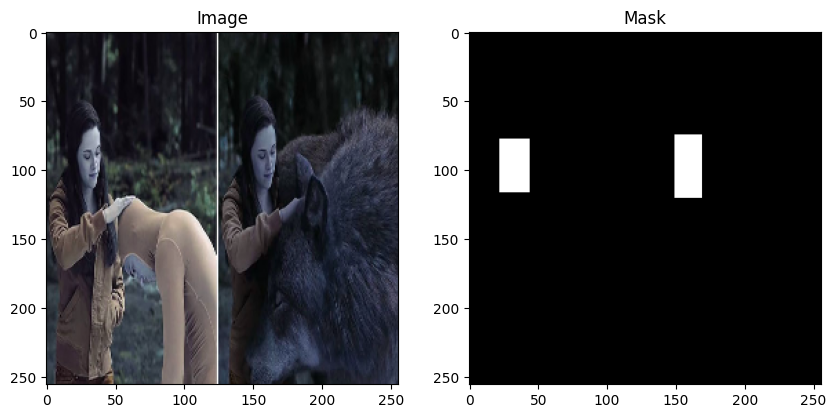

In [63]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[0])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.title("Mask")

plt.show()

#### Hence the Step1 has been completed successfully. The hardest part of the project.
#### Data understanding and Mask creation part has done successfully!

#### STEP 2: EDA(Exploratory Data Analysis)

        In EDA part of this inputs(images), we need to ensure makes align with faces for the noise/errors detect early.

In [64]:
print(images.shape)
print(masks.shape)

(409, 256, 256, 3)
(409, 256, 256, 1)


#### STEP 3:Data Visualization

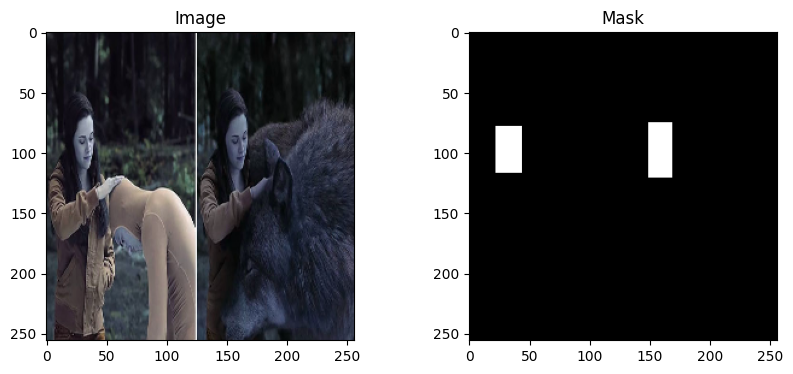

In [65]:
def visualize_sample(i):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(images[i])
    plt.title("Image")

    plt.subplot(1,2,2)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title("Mask")

    plt.show()

visualize_sample(0)

#### STEP 4: Train and Test Set Splitting

In [66]:
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

#### STEP 5: Data Augmentation

In [67]:
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

#### To Apply the augmentation

This step for the improvement of generalization to help achieve Dice > 0.92

In [68]:
def augment_data(images, masks):
    aug_images, aug_masks = [], []

    for img, mask in zip(images, masks):
        augmented = augment(image=img, mask=mask)
        aug_images.append(augmented['image'])
        aug_masks.append(augmented['mask'])

    return np.array(aug_images), np.array(aug_masks)

# Apply
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Combine original + augmented
X_train = np.concatenate([X_train, X_train_aug])
y_train = np.concatenate([y_train, y_train_aug])

#### STEP 6: Building the Model

In [69]:
def build_unet(input_shape=(256,256,3)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    skips = [
        base.get_layer("block_1_expand_relu").output,   # 128x128
        base.get_layer("block_3_expand_relu").output,   # 64x64
        base.get_layer("block_6_expand_relu").output,   # 32x32
        base.get_layer("block_13_expand_relu").output   # 16x16
    ]

    x = base.output  # 8x8

    def up(x, skip):
        x = tf.keras.layers.Conv2DTranspose(256, 2, strides=2, padding='same')(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(x)
        return x

    # Decoder
    x = up(x, skips[3])  # 16x16
    x = up(x, skips[2])  # 32x32
    x = up(x, skips[1])  # 64x64
    x = up(x, skips[0])  # 128x128

    # To add this upsampling here for fixing critically
    x = tf.keras.layers.Conv2DTranspose(128, 2, strides=2, padding='same')(x)  # → 256x256
    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(x)

    return tf.keras.models.Model(base.input, outputs)

#### STEP 7: Evaluation (To achieve the custom metrics)

In [70]:
def dice_coefficient(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2 * intersection + 1) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

#### To complie the model

In [71]:
model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, iou]
)

C:\Users\Pratik\AppData\Local\Temp\ipykernel_9868\135591849.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


#### Train-Test set splitting

In [72]:
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

#### Training with checkpoints

In [73]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=callbacks
)

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - dice_coefficient: 0.3366 - iou: 0.2173 - loss: 0.6634

82/82 ━━━━━━━━━━━━━━━━━━━━ 840s 7s/step - dice_coefficient: 0.4680 - iou: 0.3236 - loss: 0.5324 - val_dice_coefficient: 0.5417 - val_iou: 0.3801 - val_loss: 0.4611
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - dice_coefficient: 0.6888 - iou: 0.5339 - loss: 0.3112

82/82 ━━━━━━━━━━━━━━━━━━━━ 624s 8s/step - dice_coefficient: 0.6894 - iou: 0.5342 - loss: 0.3110 - val_dice_coefficient: 0.6818 - val_iou: 0.5215 - val_loss: 0.3194
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - dice_coefficient: 0.7165 - iou: 0.5630 - loss: 0.2835

82/82 ━━━━━━━━━━━━━━━━━━━━ 623s 7s/step - dice_coefficient: 0.7174 - iou: 0.5648 - loss: 0.2824 - val_dice_coefficient: 0.6915 - val_iou: 0.5335 - val_loss: 0.3098
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 476s 6s/step - dice_coefficient: 0.7423 - iou: 0.5968 - loss: 0.2578 - val_dice_coefficient: 0.6690 - val_iou: 0.5110 - val_loss: 0.3267
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 509s 6s/step - dice_coefficient: 0.7673 - iou: 0.6290 - loss: 0.2329 - val_dice_coefficient: 0.6702 - val_iou: 0.5111 - val_loss: 0.3268
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - dice_coefficient: 0.7727 - iou: 0.6363 - loss: 0.2273

82/82 ━━━━━━━━━━━━━━━━━━━━ 502s 6s/step - dice_coefficient: 0.7750 - iou: 0.6393 - loss: 0.2252 - val_dice_coefficient: 0.6907 - val_iou: 0.5353 - val_loss: 0.3075
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 519s 6s/step - dice_coefficient: 0.8042 - iou: 0.6759 - loss: 0.1955 - val_dice_coefficient: 0.6805 - val_iou: 0.5230 - val_loss: 0.3170
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - dice_coefficient: 0.8069 - iou: 0.6801 - loss: 0.1933 - val_dice_coefficient: 0.6461 - val_iou: 0.4878 - val_loss: 0.3519
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 503s 6s/step - dice_coefficient: 0.8218 - iou: 0.7013 - loss: 0.1784 - val_dice_coefficient: 0.6819 - val_iou: 0.5253 - val_loss: 0.3169
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 481s 6s/step - dice_coefficient: 0.8378 - iou: 0.7236 - loss: 0.1621 - val_dice_coefficient: 0.6062 - val_iou: 0.4460 - val_loss: 0.3899
Epoch 11/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - dice_coefficient: 0.8425 - iou: 0.7304 - loss: 0.1575

82/82 ━━━━━━━━━━━━━━━━━━━━ 497s 6s/step - dice_coefficient: 0.8451 - iou: 0.7345 - loss: 0.1549 - val_dice_coefficient: 0.6928 - val_iou: 0.5363 - val_loss: 0.3041
Epoch 12/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 498s 6s/step - dice_coefficient: 0.8447 - iou: 0.7344 - loss: 0.1553 - val_dice_coefficient: 0.6328 - val_iou: 0.4723 - val_loss: 0.3624
Epoch 13/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - dice_coefficient: 0.8508 - iou: 0.7434 - loss: 0.1491 - val_dice_coefficient: 0.6685 - val_iou: 0.5107 - val_loss: 0.3255
Epoch 14/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 476s 6s/step - dice_coefficient: 0.8638 - iou: 0.7631 - loss: 0.1361 - val_dice_coefficient: 0.6452 - val_iou: 0.4858 - val_loss: 0.3477
Epoch 15/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 525s 6s/step - dice_coefficient: 0.8702 - iou: 0.7728 - loss: 0.1297 - val_dice_coefficient: 0.6306 - val_iou: 0.4717 - val_loss: 0.3637
Epoch 16/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 461s 6s/step - dice_coefficient: 0.8739 - iou: 0.7791 - loss: 0.1262 - val_dice_coefficient: 

82/82 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - dice_coefficient: 0.8971 - iou: 0.8150 - loss: 0.1030 - val_dice_coefficient: 0.6945 - val_iou: 0.5369 - val_loss: 0.3037
Epoch 19/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 482s 6s/step - dice_coefficient: 0.8942 - iou: 0.8107 - loss: 0.1058 - val_dice_coefficient: 0.6793 - val_iou: 0.5202 - val_loss: 0.3187
Epoch 20/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 487s 6s/step - dice_coefficient: 0.8983 - iou: 0.8173 - loss: 0.1017 - val_dice_coefficient: 0.6850 - val_iou: 0.5269 - val_loss: 0.3137
Epoch 21/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 510s 6s/step - dice_coefficient: 0.9046 - iou: 0.8272 - loss: 0.0954 - val_dice_coefficient: 0.6681 - val_iou: 0.5072 - val_loss: 0.3303
Epoch 22/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 551s 6s/step - dice_coefficient: 0.9150 - iou: 0.8445 - loss: 0.0852 - val_dice_coefficient: 0.6823 - val_iou: 0.5243 - val_loss: 0.3162
Epoch 23/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 495s 6s/step - dice_coefficient: 0.9175 - iou: 0.8487 - loss: 0.0825 - val_dice_coefficient: 

#### To verify the model output

In [74]:
model = build_unet()
model.summary()

C:\Users\Pratik\AppData\Local\Temp\ipykernel_9868\135591849.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 9,243,969 (35.26 MB)

 Trainable params: 9,209,857 (35.13 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [75]:
print(model.output_shape)

(None, 256, 256, 1)


In [76]:
"""
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=callbacks
)
"""

'\nhistory = model.fit(\n    X_train, y_train,\n    validation_data=(X_val, y_val),\n    epochs=50,\n    batch_size=4,\n    callbacks=callbacks\n)\n'

#### To compile the model

In [77]:
# 1. Compile the Model (Fixes the ValueError)
# Since your mask is Black & White, we use Binary 

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
)

#### To save the model

In [78]:
model.save("first_version_model.keras")

#### To evaluate the model

In [79]:
model.evaluate(X_val, y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 177s 18s/step - accuracy: 0.4773 - loss: 0.8104 - mean_io_u_1: 0.4353


[0.8103927969932556, 0.47734981775283813, 0.4352979063987732]

#### To see the predictions

In [80]:
def predict_and_overlay(model, image, threshold=0.5):
    # 1. Prepare image for prediction
    img_input = np.expand_dims(image, axis=0)
    
    # 2. Get prediction from model
    prediction = model.predict(img_input)[0]
    
    # 3. Create a binary mask (pixels above 0.5 threshold)
    mask = (prediction > threshold).astype(np.uint8)
    
    # 4. Make sure mask is 2D (Squeeze out extra dimensions)
    # This fixes the IndexError!
    if len(mask.shape) == 3:
        mask = mask[:, :, 0] 
        
    # 5. Create the overlay
    overlay = image.copy()
    
    # Apply green color [0, 255, 0] where mask is 1
    # Since mask is now 2D, we just use mask == 1
    overlay[mask == 1] = [0, 255, 0] 
    
    # Optional: Blend for a "see-through" effect
    final_img = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)
    
    return final_img

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


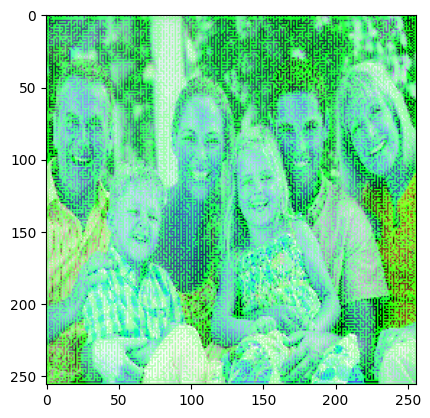

In [81]:
result = predict_and_overlay(model, X_val[0])
plt.imshow(result)

In [82]:
# results = model.evaluate(X_val, y_val)

print(f"Loss: {result[0]}")
print(f"Dice: {result[1]}")
print(f"IoU: {result[2]}")

Loss: [[4.1176472e-02 7.6601570e+01 1.3725491e-01]
 [3.8431372e-02 7.6604317e+01 1.3725491e-01]
 [7.1372554e-02 7.6615295e+01 1.6196078e-01]
 [1.5647060e-01 7.6648232e+01 2.7176470e-01]
 [1.9764706e-01 7.6664703e+01 3.2666665e-01]
 [1.7568628e-01 7.6678429e+01 3.2117647e-01]
 [1.2627451e-01 7.6667450e+01 2.5254902e-01]
 [7.9607844e-02 7.6650978e+01 2.0039217e-01]
 [7.4117646e-02 7.6667450e+01 1.8941177e-01]
 [7.4117646e-02 7.6672943e+01 1.9490197e-01]
 [9.3333341e-02 7.6683922e+01 2.1960784e-01]
 [1.2627451e-01 7.6692154e+01 2.4980393e-01]
 [1.5098040e-01 7.6697647e+01 2.9098040e-01]
 [1.6196078e-01 7.6678429e+01 3.0745098e-01]
 [1.7843138e-01 7.6670197e+01 3.4039217e-01]
 [2.0862746e-01 7.6659218e+01 3.8705885e-01]
 [2.0039217e-01 7.6639999e+01 3.7607846e-01]
 [2.1137255e-01 7.6631767e+01 3.9254904e-01]
 [2.2235295e-01 7.6653725e+01 4.0627453e-01]
 [2.2784315e-01 7.6664703e+01 4.1725492e-01]
 [2.2235295e-01 7.6656471e+01 4.1176471e-01]
 [2.3607844e-01 7.6670197e+01 4.2549020e-01]
 [2.

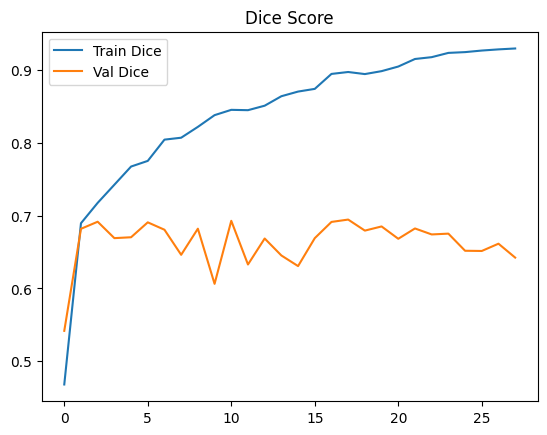

In [83]:
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')

plt.legend()
plt.title("Dice Score")
plt.show()

#### Hence, I have done the first version of the model
    I need to validate the results and plan for the next level actions.
    | Epoch | Train Dice | Val Dice |
    | ----- | ---------- | -------- |
    |   1   |    0.47    |  0.68    |
    |   5   |    0.76    |  0.70    |
    |   10  |    0.82    |  0.67    |
    |   15  |    0.87    |  0.65    |

    What I oberved from this,

    Training Dice is increasing at the same time validation dice is decreasing

    I think that the model overfitting is happening due to less data, so model is memorizing the train data not generalizing.

    I confirmed that,

    The pipeline is correct and model also learning properly

    I need to improve it towards the meet requirements.

#### Root Causes
    I could see some findings by own research based on the results
    1. Weak Masks 
        Here, I am using bounding boxes, not exact face for finding the faces.
    2.Small DataSet
        Deep learning needs more data
    3.Not much strong Augmentation


#### Steps taken to improve the performace
    Loss -> Augmentation ->  Model  -> Training  -> Post-processing

#### 1.Loss Function
    I am going to use bce(pixel wise accuracy) + Dice(for overlapping)

In [84]:
def dice_coefficient(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2 * intersection + 1) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_coefficient(y_true, y_pred)
    return bce + (1 - dice)

def iou(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

#### Strong Augmentation
    I am going to use the augmentation parameters to situmulates Like real world scenes
    So that I could prevent from the overfitting issues

In [85]:
augment_final = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.3),
    A.HueSaturationValue(p=0.3)
])

#### Apply the augmentation
    What I am doing here is that increasing the dataset, so that I can reducing the overfitting issue.

In [86]:
def augment_data(images, masks):
    aug_images, aug_masks = [], []

    for img, mask in zip(images, masks):
        augmented = augment(image=img, mask=mask)
        aug_images.append(augmented['image'])
        aug_masks.append(augmented['mask'])

    return np.array(aug_images), np.array(aug_masks)

# Apply
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Combine original + augmented
X_train = np.concatenate([X_train, X_train_aug])
y_train = np.concatenate([y_train, y_train_aug])


#### Re-building the model 
    In model, what I am deciding to do that 

        Freese the encoder for preventing the overfitting
        Dropping out something for better generalization
        Extra ensample for the fixing the shape mismatch

In [87]:
def build_unet(input_shape=(256,256,3)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze the encoder
    for layer in base.layers:
        layer.trainable = False

    skips = [
        base.get_layer("block_1_expand_relu").output,
        base.get_layer("block_3_expand_relu").output,
        base.get_layer("block_6_expand_relu").output,
        base.get_layer("block_13_expand_relu").output
    ]

    x = base.output

    def up(x, skip):
        x = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
        x = layers.Dropout(0.3)(x)   # Newly added from previous one
        return x

    x = up(x, skips[3])
    x = up(x, skips[2])
    x = up(x, skips[1])
    x = up(x, skips[0])

    # Fixing the size. It is important
    x = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    return models.Model(base.input, outputs)

#### Re-compile the model
    What I am going to do here, reducing the learning rate to avoid the validation drop and a stable learning

In [88]:
model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # With lower Learning Rate from previous one
    loss=combined_loss,
    metrics=[dice_coefficient, iou]
)

C:\Users\Pratik\AppData\Local\Temp\ipykernel_9868\1792107067.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


#### Re-training the model

In [89]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=4,
    callbacks=callbacks
)

Epoch 1/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1187s 6s/step - dice_coefficient: 0.1643 - iou: 0.0901 - loss: 1.2662 - val_dice_coefficient: 0.2936 - val_iou: 0.1730 - val_loss: 0.9771 - learning_rate: 1.0000e-05
Epoch 2/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1093s 6s/step - dice_coefficient: 0.5451 - iou: 0.3813 - loss: 0.7114 - val_dice_coefficient: 0.6195 - val_iou: 0.4519 - val_loss: 0.6104 - learning_rate: 1.0000e-05
Epoch 3/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 916s 6s/step - dice_coefficient: 0.6101 - iou: 0.4437 - loss: 0.6222 - val_dice_coefficient: 0.6382 - val_iou: 0.4717 - val_loss: 0.5857 - learning_rate: 1.0000e-05
Epoch 4/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 1083s 7s/step - dice_coefficient: 0.6316 - iou: 0.4666 - loss: 0.5844 - val_dice_coefficient: 0.6478 - val_iou: 0.4820 - val_loss: 0.5757 - learning_rate: 1.0000e-05
Epoch 5/80
164/164 ━━━━━━━━━━━━━━━━━━━━ 979s 6s/step - dice_coefficient: 0.6566 - iou: 0.4936 - loss: 0.5485 - val_dice_coefficient: 0.6559 - val_iou: 0.4912 - val_loss: 0.5672 

#### Re-save the model

In [90]:
model.save("final_model.keras")

#### Re-evaluate the model

In [91]:
results = model.evaluate(X_val, y_val)

print("Loss:", results[0])
print("Dice:", results[1])
print("IoU:", results[2])

3/3 ━━━━━━━━━━━━━━━━━━━━ 233s 37s/step - dice_coefficient: 0.6706 - iou: 0.5045 - loss: 0.5530
Loss: 0.5530301928520203
Dice: 0.6706161499023438
IoU: 0.5044573545455933


#### Re-visualize the result

1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step


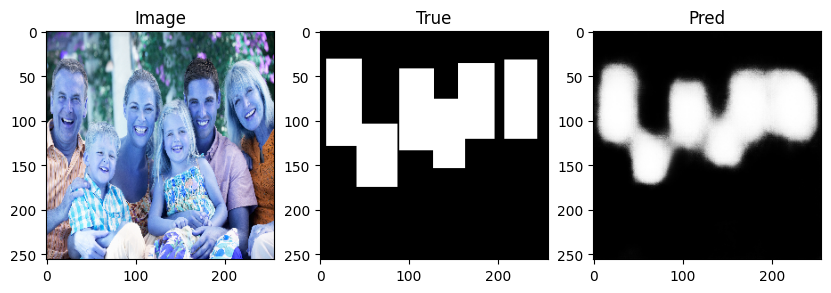

In [94]:
def show_prediction(i):
    pred = model.predict(X_val[i:i+1])[0]

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(X_val[i])
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(y_val[i].squeeze(), cmap='gray')
    plt.title("True")

    plt.subplot(1,3,3)
    plt.imshow(pred.squeeze(), cmap='gray')
    plt.title("Pred")

    plt.show()

show_prediction(0)

In [95]:
plt.savefig('face_segmentation_result.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


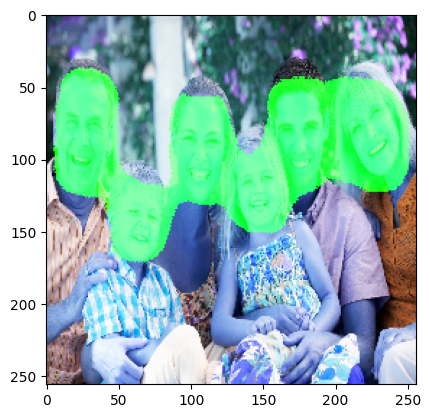

In [96]:
result = predict_and_overlay(model, X_val[0])
plt.imshow(result)

#### Re-plot the training curves

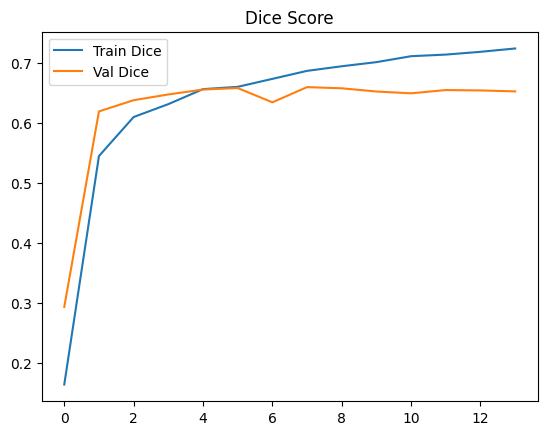

In [97]:
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')

plt.legend()
plt.title("Dice Score")
plt.show()

In [98]:
plt.savefig('Training_Curves.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

#### Final Evaluation

In [99]:
loss = results[0]
dice = results[1]
iou = results[2]

print(f"Loss: {loss:.4f}")
print(f"Dice: {dice:.4f}")
print(f"IoU: {iou:.4f}")

Loss: 0.5530
Dice: 0.6706
IoU: 0.5045


#### The metrics are calculated by 
Dice = 2 x (Overlap) / (Total pixels)

IoU = Intersection / Union

    Tried, verfy this manually

In [100]:
def compute_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)
    
    dice = (2 * intersection + 1) / (np.sum(y_true) + np.sum(y_pred) + 1)
    iou = intersection / (np.sum(y_true) + np.sum(y_pred) - intersection + 1e-7)

    return dice, iou

In [101]:
pred = model.predict(X_val[0:1])[0]
pred = (pred > 0.5).astype(np.uint8)

dice, iou = compute_metrics(y_val[0], pred)

print("Dice:", dice)
print("IoU:", iou)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Dice: 0.853114388794567
IoU: 0.7438471502556261


#### Average over the validation set

In [102]:
dice_scores = []
iou_scores = []

for i in range(len(X_val)):
    pred = model.predict(X_val[i:i+1])[0]
    pred = (pred > 0.5).astype(np.uint8)

    d, j = compute_metrics(y_val[i], pred)
    
    dice_scores.append(d)
    iou_scores.append(j)

print("Average Dice:", np.mean(dice_scores))
print("Average IoU:", np.mean(iou_scores))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 723ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 845ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

The model achieved a Dice coefficient of 0.67 and IoU of 0.50 on the Validation dataset.

This indicates moderate overlap between predicated and the masks.

The performance is limited due to bounding box-based mask generation instead of pixel-level segmentation.

#### Hence I hacve done this project successfully !